# Geodesic, Pullback Metric & FlatVI

Hands-on notebook covering three interconnected theory notes:
- **`05-geodesic.md`** — Geodesic distance, why LERP fails on manifolds, Exp/Log maps
- **`06-pullback-metric.md`** — Pullback metric $g_Z = J^T J$, measuring decoder distortion
- **`07-flatvi.md`** — FlatVI: forcing the latent space to be flat via a Frobenius penalty

The three topics form a progression: geodesics expose the *problem* (LERP fails) →
the pullback metric provides the *diagnosis* (non-isotropic decoder Jacobian) →
FlatVI delivers the *cure* (penalise deviation from $\alpha I$).

Exercises: implement SLERP, the pullback metric via finite-difference Jacobian, and the flattening loss.

All text is in English to match the project language rules for artifacts.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 — registers 3-D projection
from collections.abc import Callable

from sklearn.datasets import make_swiss_roll
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import pairwise_distances

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(42)

---

## Part 1 — Geodesic (05-geodesic.md)

> *A geodesic is the shortest curve connecting two points that lies entirely on the manifold.*

Sections:
1. **1.1** Why LERP fails on manifolds
2. **1.2** SLERP — geodesic interpolation on $S^1$ *(exercise)*
3. **1.3** Exponential and Logarithmic maps
4. **1.4** Swiss Roll: LERP shortcuts through empty latent space

### 1.1 — Why LERP Fails on Manifolds

**Linear interpolation (LERP)** between two points $a$ and $b$:
$$Y(t) = (1-t)\,a + t\,b, \quad t \in [0,1]$$

In flat Euclidean space this gives the shortest path. But on a *curved manifold*:
- The midpoint $(1-t)a + tb$ does not generally lie on the manifold.
- The path "cuts through" the ambient space instead of staying on the surface.
- In a deep learning latent space, this means traversing regions of near-zero data density,
  producing blurry or unrealistic decoded outputs.

**Demo:** the unit circle $S^1$ is the simplest non-trivial manifold.
LERP between two points on $S^1$ dips inside the circle — it leaves the manifold.

In [2]:
# Two points on the unit circle S^1
theta_a, theta_b = np.pi / 6, 5 * np.pi / 6   # 30 deg and 150 deg
a = np.array([np.cos(theta_a), np.sin(theta_a)])
b = np.array([np.cos(theta_b), np.sin(theta_b)])

ts = np.linspace(0, 1, 51)
lerp_path  = np.outer(1 - ts, a) + np.outer(ts, b)   # (51, 2)
lerp_norms = np.linalg.norm(lerp_path, axis=1)

print('LERP between two unit-circle points:')
print(f'  a = {a}  (norm = {np.linalg.norm(a):.4f})')
print(f'  b = {b}  (norm = {np.linalg.norm(b):.4f})')
print()
print(f'  Midpoint (t=0.5) : {lerp_path[25]}')
print(f'  Midpoint norm    : {lerp_norms[25]:.4f}  <- should be 1.0 to stay on S^1')
print(f'  Max deviation    : {abs(1 - lerp_norms).max():.4f}')

LERP between two unit-circle points:
  a = [0.866 0.5  ]  (norm = 1.0000)
  b = [-0.866  0.5  ]  (norm = 1.0000)

  Midpoint (t=0.5) : [0.  0.5]
  Midpoint norm    : 0.5000  <- should be 1.0 to stay on S^1
  Max deviation    : 0.5000


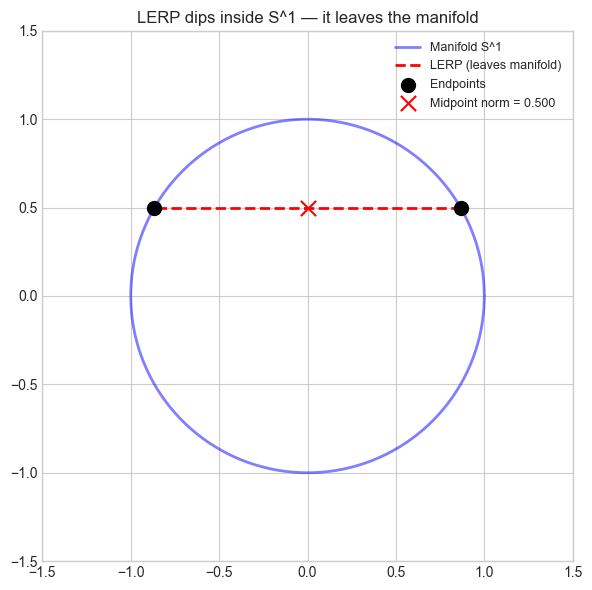

In [3]:
circle_angles = np.linspace(0, 2 * np.pi, 300)
circle = np.column_stack([np.cos(circle_angles), np.sin(circle_angles)])

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(circle[:, 0], circle[:, 1], 'b-', linewidth=2, alpha=0.5, label='Manifold S^1')
ax.plot(lerp_path[:, 0], lerp_path[:, 1], 'r--', linewidth=2, label='LERP (leaves manifold)')
ax.scatter([a[0], b[0]], [a[1], b[1]], color='black', s=100, zorder=5, label='Endpoints')
ax.scatter(*lerp_path[25], color='red', s=120, marker='x', zorder=6,
           label=f'Midpoint norm = {lerp_norms[25]:.3f}')
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')
ax.set_title('LERP dips inside S^1 — it leaves the manifold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### 1.2 — SLERP: Geodesic Interpolation on $S^{n-1}$  *(Exercise 1)*

**Spherical Linear Interpolation (SLERP)** moves at constant angular speed along the great-circle arc:

$$\text{SLERP}(u, v, t) = \frac{\sin((1-t)\theta)}{\sin\theta}\,u + \frac{\sin(t\theta)}{\sin\theta}\,v$$

where $\theta = \arccos(u \cdot v)$ is the angle between $u$ and $v$.

Properties:
- $\text{SLERP}(u, v, 0) = u$ and $\text{SLERP}(u, v, 1) = v$
- All intermediate points lie on $S^{n-1}$ (norm = 1)
- Constant angular speed: equal $t$-steps subtend equal arc lengths

When $\theta \approx 0$ ($u \approx v$), the formula is numerically degenerate — fall back to LERP.

In [4]:
def slerp(u: np.ndarray, v: np.ndarray, t: float) -> np.ndarray:
    '''
    Spherical Linear Interpolation between unit vectors u and v at t in [0, 1].
    Moves at constant angular speed along the great-circle arc on S^(n-1).

    Formula:  sin((1-t)*theta)/sin(theta) * u  +  sin(t*theta)/sin(theta) * v
    where theta = arccos(u . v)
    '''
    # TODO:
    # 1. cos_theta = clip(u . v, -1, 1)  — clip avoids arccos domain errors
    # 2. theta = arccos(cos_theta)
    # 3. If theta < 1e-8 (u ~= v), return linear blend as safe fallback
    # 4. Return the SLERP formula
    # raise NotImplementedError('TODO: implement slerp')

    cos_theta = float(np.clip(np.dot(u, v), -1.0, 1.0))
    theta = np.arccos(cos_theta)
    if abs(theta) < 1e-8:
        return (1.0 - t) * u + t * v
    return (np.sin((1.0 - t) * theta) / np.sin(theta)) * u + \
           (np.sin(t * theta) / np.sin(theta)) * v

In [5]:
slerp_path  = np.array([slerp(a, b, t) for t in ts])
slerp_norms = np.linalg.norm(slerp_path, axis=1)

assert np.allclose(slerp_norms, 1.0, atol=1e-6), 'SLERP must stay on S^1'
assert np.allclose(slerp(a, b, 0.0), a, atol=1e-8), 'SLERP(t=0) must equal a'
assert np.allclose(slerp(a, b, 1.0), b, atol=1e-8), 'SLERP(t=1) must equal b'

# Verify constant angular speed
arc_diffs = np.diff(np.arctan2(slerp_path[:, 1], slerp_path[:, 0]))
arc_cv = arc_diffs.std() / abs(arc_diffs.mean())   # coefficient of variation

print('Exercise 1 - SLERP looks good.')
print(f'  Max norm deviation from 1 : {abs(slerp_norms - 1.0).max():.2e}')
print(f'  Angular speed CoV         : {arc_cv:.2e}  (0 = perfectly constant)')

Exercise 1 - SLERP looks good.
  Max norm deviation from 1 : 3.33e-16
  Angular speed CoV         : 3.45e-15  (0 = perfectly constant)


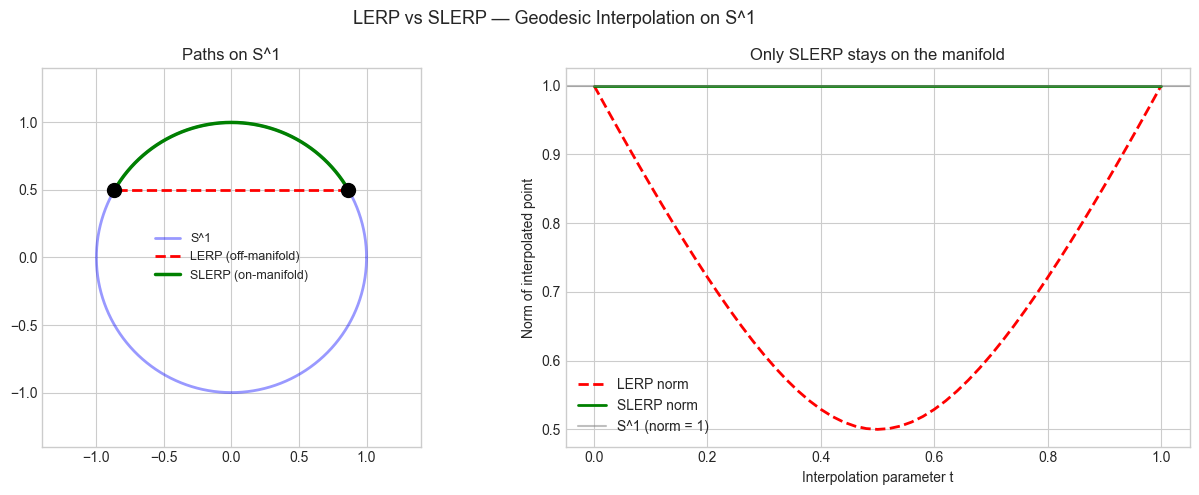

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(circle[:, 0], circle[:, 1], 'b-', linewidth=2, alpha=0.4, label='S^1')
ax.plot(lerp_path[:, 0],  lerp_path[:, 1],  'r--', linewidth=2,   label='LERP (off-manifold)')
ax.plot(slerp_path[:, 0], slerp_path[:, 1], 'g-',  linewidth=2.5, label='SLERP (on-manifold)')
ax.scatter([a[0], b[0]], [a[1], b[1]], color='black', s=100, zorder=5)
ax.set_aspect('equal')
ax.set_xlim(-1.4, 1.4)
ax.set_ylim(-1.4, 1.4)
ax.set_title('Paths on S^1')
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(ts, lerp_norms,  'r--', linewidth=2, label='LERP norm')
ax.plot(ts, slerp_norms, 'g-',  linewidth=2, label='SLERP norm')
ax.axhline(1.0, color='gray', linestyle='-', alpha=0.5, label='S^1 (norm = 1)')
ax.set_xlabel('Interpolation parameter t')
ax.set_ylabel('Norm of interpolated point')
ax.set_title('Only SLERP stays on the manifold')
ax.legend()

plt.suptitle('LERP vs SLERP — Geodesic Interpolation on S^1', fontsize=13)
plt.tight_layout()
plt.show()

### 1.3 — Exponential and Logarithmic Maps

The Exp/Log pair provides the general recipe for geodesic interpolation on any Riemannian manifold:

$$Y(t) = \text{Exp}_{Y_0}\!\bigl(t \cdot \text{Log}_{Y_0}(Y_1)\bigr)$$

| Map | Input | Output | Meaning |
|---|---|---|---|
| $\text{Log}_p(q)$ | two manifold points | tangent vector at $p$ | direction and distance from $p$ to $q$ |
| $\text{Exp}_p(v)$ | point $p$ + tangent $v$ | manifold point | follow $v$ for $\|v\|$ steps along geodesic |

**On $S^1$:**
- $\text{Log}_p(q) = \theta \cdot \hat{v}$ where $\theta = \arccos(p \cdot q)$ and $\hat{v}$ is the unit tangent pointing from $p$ toward $q$.
- $\text{Exp}_p(v) = \cos(\|v\|)\,p + \sin(\|v\|)\,\hat{v}$

Key identity: $\text{Exp}_p(\text{Log}_p(q)) = q$ (round trip).

In [7]:
def log_map_s1(p: np.ndarray, q: np.ndarray) -> np.ndarray:
    '''Log map on S^1: tangent vector at p pointing toward q, with length = geodesic distance.'''
    cos_theta = float(np.clip(np.dot(p, q), -1.0, 1.0))
    theta = np.arccos(cos_theta)
    if abs(theta) < 1e-10:
        return np.zeros(2)
    q_tangent = q - np.dot(p, q) * p       # project q onto tangent plane at p
    return theta * q_tangent / np.linalg.norm(q_tangent)


def exp_map_s1(p: np.ndarray, v: np.ndarray) -> np.ndarray:
    '''Exp map on S^1: follow tangent vector v from p for ||v|| steps.'''
    norm_v = np.linalg.norm(v)
    if norm_v < 1e-10:
        return p.copy()
    return np.cos(norm_v) * p + np.sin(norm_v) * (v / norm_v)


# Round-trip verification: Exp(p, Log(p, q)) == q
log_vec   = log_map_s1(a, b)
recovered = exp_map_s1(a, log_vec)

print(f'Log map at a pointing to b   : {log_vec}')
print(f'Geodesic distance a -> b     : {np.linalg.norm(log_vec):.4f} rad')
print(f'Expected (theta_b - theta_a) : {theta_b - theta_a:.4f} rad')
print(f'Exp(a, Log(a, b)) == b       : {np.allclose(recovered, b, atol=1e-7)}')
print()

# Geodesic interpolation: Y(t) = Exp_{a}(t * Log_{a}(b))
geod_path  = np.array([exp_map_s1(a, t * log_vec) for t in ts])
geod_norms = np.linalg.norm(geod_path, axis=1)

print(f'Geodesic interp stays on S^1 : {np.allclose(geod_norms, 1.0, atol=1e-7)}')
print(f'Geodesic path == SLERP path  : {np.allclose(geod_path, slerp_path, atol=1e-7)}')
print('-> Exp/Log formula reproduces SLERP exactly on S^1')

Log map at a pointing to b   : [-1.0472  1.8138]
Geodesic distance a -> b     : 2.0944 rad
Expected (theta_b - theta_a) : 2.0944 rad
Exp(a, Log(a, b)) == b       : True

Geodesic interp stays on S^1 : True
Geodesic path == SLERP path  : True
-> Exp/Log formula reproduces SLERP exactly on S^1


### 1.4 — Swiss Roll: LERP Shortcuts Through Empty Space

In deep learning, the decoder distorts the latent space so that it is no longer flat.
Two points that are close in latent space may be on *different coil layers* of the data manifold —
a straight-line interpolation in latent space cuts through a low-density void.

**Consequence:** the decoded outputs along the interpolation path can be blurry,
physically impossible, or semantically meaningless.

**Metric:** distance from each interpolated 3-D point to the nearest actual data point
quantifies how far the LERP path strays from the manifold.

In [8]:
X_roll, t_roll = make_swiss_roll(n_samples=3000, noise=0.1, random_state=42)

# Find the misleading pair: closest Euclidean distance across inner vs outer coil
idx_sorted_t = np.argsort(t_roll)
inner_pool, outer_pool = idx_sorted_t[:60], idx_sorted_t[-60:]

cross     = pairwise_distances(X_roll[inner_pool], X_roll[outer_pool])
i_b, j_b  = np.unravel_index(cross.argmin(), cross.shape)
idx_s, idx_e = inner_pool[i_b], outer_pool[j_b]
start, end   = X_roll[idx_s], X_roll[idx_e]

lerp_3d    = np.outer(1 - ts, start) + np.outer(ts, end)
knn        = NearestNeighbors(n_neighbors=1).fit(X_roll)
off_mfd, _ = knn.kneighbors(lerp_3d)
off_mfd    = off_mfd.ravel()

print(f'Start: t={t_roll[idx_s]:.2f}   End: t={t_roll[idx_e]:.2f}')
print(f'Euclidean 3D distance : {np.linalg.norm(start - end):.3f}')
print()
print(f'{"Interp t":>10} | {"Dist to manifold":>18}')
print('-' * 34)
for i in range(0, len(ts), 10):
    print(f'{ts[i]:>10.2f} | {off_mfd[i]:>18.3f}')
print()
print(f'Max off-manifold distance: {off_mfd.max():.3f}  (at t={ts[off_mfd.argmax()]:.2f})')
print('-> LERP shortcut goes through empty latent space!')

Start: t=4.88   End: t=13.96
Euclidean 3D distance : 18.312

  Interp t |   Dist to manifold
----------------------------------
      0.00 |              0.000
      0.20 |              3.662
      0.40 |              4.050
      0.60 |              0.921
      0.80 |              2.438
      1.00 |              0.000

Max off-manifold distance: 4.899  (at t=0.30)
-> LERP shortcut goes through empty latent space!


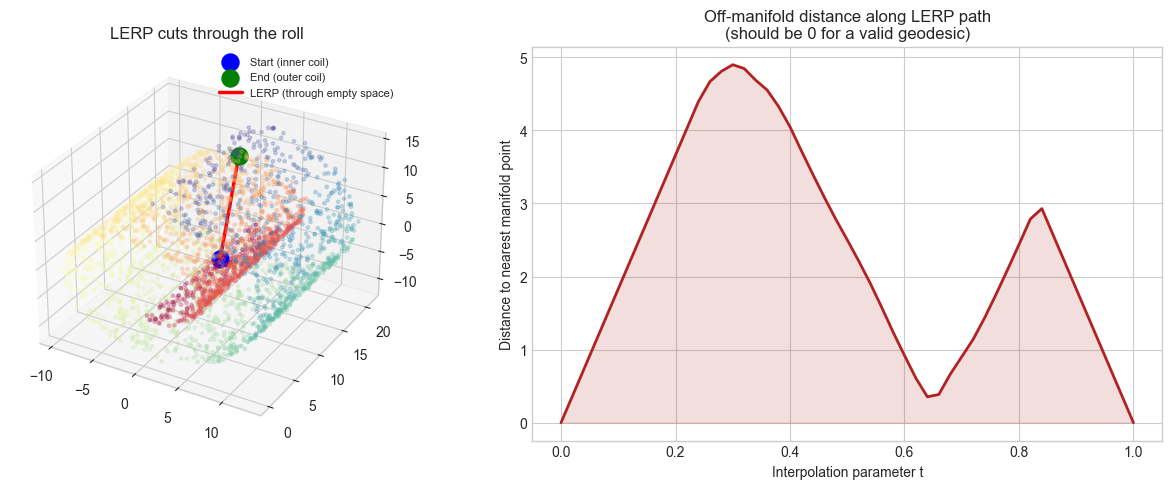

In [9]:
fig = plt.figure(figsize=(13, 5))

ax3d = fig.add_subplot(121, projection='3d')
ax3d.scatter(X_roll[:, 0], X_roll[:, 1], X_roll[:, 2],
             c=t_roll, cmap='Spectral', s=6, alpha=0.25)
ax3d.scatter(*start, color='blue',  s=150, zorder=10, label='Start (inner coil)')
ax3d.scatter(*end,   color='green', s=150, zorder=10, label='End (outer coil)')
line = lerp_3d
ax3d.plot(line[:, 0], line[:, 1], line[:, 2], 'r-', linewidth=2.5,
          label='LERP (through empty space)')
ax3d.set_title('LERP cuts through the roll')
ax3d.legend(fontsize=8)

ax2d = fig.add_subplot(122)
ax2d.plot(ts, off_mfd, color='firebrick', linewidth=2)
ax2d.fill_between(ts, off_mfd, alpha=0.15, color='firebrick')
ax2d.set_xlabel('Interpolation parameter t')
ax2d.set_ylabel('Distance to nearest manifold point')
ax2d.set_title('Off-manifold distance along LERP path\n(should be 0 for a valid geodesic)')

plt.tight_layout()
plt.show()

---

## Part 2 — Pullback Metric (06-pullback-metric.md)

> *Transfer the data-space distance structure back into the latent space through the decoder Jacobian.*

Sections:
1. **2.1** Pullback metric $g_Z(z) = J_{\psi}(z)^T J_{\psi}(z)$ *(exercise)*
2. **2.2** Visualising decoder distortion via metric ellipses

### 2.1 — Pullback Metric $g_Z(z) = J^T J$  *(Exercise 2)*

Let $\psi: \mathcal{Z} \to \mathcal{X}$ be the decoder. If $\mathcal{X}$ has the standard Euclidean metric,
the **pullback metric** at $z$ is:

$$g_Z(z) = J_{\psi}(z)^T\, J_{\psi}(z)$$

where $J_{\psi}(z) \in \mathbb{R}^{D \times d}$ is the Jacobian of the decoder.

**Interpretation of $g_Z(z)$:**
- A unit ball in latent space (Euclidean) maps to an ellipsoid in data space.
  The axes of that ellipsoid are the left-singular vectors of $J$, scaled by the singular values.
- The induced length of a latent displacement $dz$ is $\|dz\|_{g_Z}^2 = dz^T g_Z(z)\, dz = \|J\,dz\|^2$.
- If $g_Z(z) = \alpha I$ everywhere: the decoder is *isometric* (uniformly scaled Euclidean),
  and latent straight lines map to data-space geodesics. That is the **FlatVI condition**.

**Numerical Jacobian:** use central finite differences $J_{ij} \approx \dfrac{f_i(z + \varepsilon e_j) - f_i(z - \varepsilon e_j)}{2\varepsilon}$.

In [10]:
def finite_diff_jacobian(
    f: Callable[[np.ndarray], np.ndarray],
    z: np.ndarray,
    eps: float = 1e-4,
) -> np.ndarray:
    '''
    Compute the Jacobian of f: R^d -> R^D at z using central finite differences.
    Returns shape (D, d) — row i = partial derivatives of f_i w.r.t. all inputs.
    '''
    d = len(z)
    D = len(f(z))
    J = np.zeros((D, d))
    for i in range(d):
        delta    = np.zeros(d)
        delta[i] = eps
        J[:, i]  = (f(z + delta) - f(z - delta)) / (2.0 * eps)
    return J


def pullback_metric(
    decoder: Callable[[np.ndarray], np.ndarray],
    z: np.ndarray,
    eps: float = 1e-4,
) -> np.ndarray:
    '''
    Compute the pullback metric g_Z(z) = J(z)^T J(z).

    A unit ball in latent space maps (via J) to an ellipsoid in data space.
    g_Z tells us how that ellipsoid deforms: eigenvalue lambda_i means the
    i-th direction is stretched by sqrt(lambda_i) relative to latent space.

    If g_Z(z) = alpha * I everywhere, LERP in latent space = geodesic in data space.

    Returns: (d, d) symmetric positive semi-definite matrix.
    '''
    # TODO:
    # 1. Compute J = finite_diff_jacobian(decoder, z, eps), shape (D, d).
    # 2. Return J.T @ J.
    # raise NotImplementedError('TODO: implement pullback_metric')

    J = finite_diff_jacobian(decoder, z, eps)
    return J.T @ J

In [11]:
# Decoder: (r, theta) -> (exp(r/2)*cos(theta),  exp(r/2)*sin(theta))
# Analytical Jacobian at z=(0,0):
#   d/dr    = [0.5*cos(0), 0.5*sin(0)] = [0.5, 0]
#   d/dtheta= [-sin(0),    cos(0)     ] = [0,   1]
#   J = [[0.5, 0], [0, 1]]  ->  g = J^T J = [[0.25, 0], [0, 1]]

def decoder_polar(z: np.ndarray) -> np.ndarray:
    '''Polar decoder: (r, theta) -> (e^{r/2} cos(theta), e^{r/2} sin(theta)).'''
    return np.array([
        np.exp(z[0] * 0.5) * np.cos(z[1]),
        np.exp(z[0] * 0.5) * np.sin(z[1]),
    ])


z0 = np.array([0.0, 0.0])
g0_numerical  = pullback_metric(decoder_polar, z0)
g0_analytical = np.array([[0.25, 0.0], [0.0, 1.0]])

print('Numerical  g(0, 0):', g0_numerical)
print('Analytical g(0, 0):', g0_analytical)
assert np.allclose(g0_numerical, g0_analytical, atol=1e-5)
print('Exercise 2 - pullback_metric looks good.')

# Observe how the metric changes away from origin
print()
for r_val in [0.0, 1.0, 2.0]:
    z = np.array([r_val, 0.0])
    g = pullback_metric(decoder_polar, z)
    eigs = np.linalg.eigvalsh(g)
    print(f'  r={r_val:.1f}: eigenvalues = {eigs}  (ratio = {eigs.max()/eigs.min():.2f})')
print('-> Metric becomes more anisotropic as r increases (decoder stretches more)')

Numerical  g(0, 0): [[0.25 0.  ]
 [0.   1.  ]]
Analytical g(0, 0): [[0.25 0.  ]
 [0.   1.  ]]
Exercise 2 - pullback_metric looks good.

  r=0.0: eigenvalues = [0.25 1.  ]  (ratio = 4.00)
  r=1.0: eigenvalues = [0.6796 2.7183]  (ratio = 4.00)
  r=2.0: eigenvalues = [1.8473 7.3891]  (ratio = 4.00)
-> Metric becomes more anisotropic as r increases (decoder stretches more)


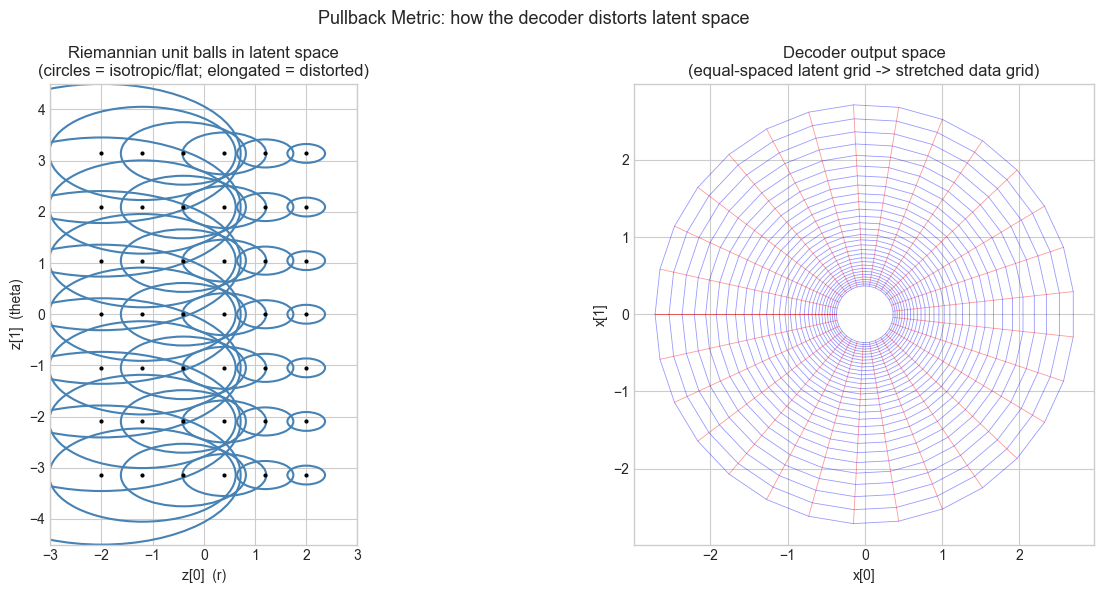

In [12]:
grid_z1 = np.linspace(-2, 2, 6)
grid_z2 = np.linspace(-np.pi, np.pi, 7)
scale   = 0.5

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Latent space with metric ellipses (Riemannian unit balls) ---
ax = axes[0]
for z1 in grid_z1:
    for z2 in grid_z2:
        z = np.array([z1, z2])
        g = pullback_metric(decoder_polar, z)
        evals, evecs = np.linalg.eigh(g)           # evals ascending
        # Semi-axes of Riemannian unit ball = 1/sqrt(eigenvalue)
        sa = scale / np.sqrt(max(evals[0], 1e-8))  # largest axis (smallest eigenvalue)
        sb = scale / np.sqrt(max(evals[1], 1e-8))
        angle = np.degrees(np.arctan2(evecs[1, 0], evecs[0, 0]))
        el = patches.Ellipse(
            xy=(z1, z2), width=2 * sa, height=2 * sb, angle=angle,
            edgecolor='steelblue', facecolor='none', linewidth=1.5
        )
        ax.add_patch(el)
        ax.plot(z1, z2, 'k.', markersize=4)

ax.set_xlim(-3, 3)
ax.set_ylim(-4.5, 4.5)
ax.set_aspect('equal')
ax.set_xlabel('z[0]  (r)')
ax.set_ylabel('z[1]  (theta)')
ax.set_title('Riemannian unit balls in latent space\n'
             '(circles = isotropic/flat; elongated = distorted)')

# --- Decoded grid in data space ---
ax = axes[1]
dense_r     = np.linspace(-2, 2, 30)
dense_theta = np.linspace(-np.pi, np.pi, 30)
for r_val in dense_r:
    pts = np.array([decoder_polar(np.array([r_val, th])) for th in dense_theta])
    ax.plot(pts[:, 0], pts[:, 1], 'b-', linewidth=0.6, alpha=0.4)
for th_val in dense_theta:
    pts = np.array([decoder_polar(np.array([r, th_val])) for r in dense_r])
    ax.plot(pts[:, 0], pts[:, 1], 'r-', linewidth=0.6, alpha=0.4)
ax.set_aspect('equal')
ax.set_xlabel('x[0]')
ax.set_ylabel('x[1]')
ax.set_title('Decoder output space\n'
             '(equal-spaced latent grid -> stretched data grid)')

plt.suptitle('Pullback Metric: how the decoder distorts latent space', fontsize=13)
plt.tight_layout()
plt.show()

---

## Part 3 — FlatVI (07-flatvi.md)

> *Instead of navigating curved geodesics, force the decoder to flatten the space so LERP becomes valid.*

Sections:
1. **3.1** Flattening loss $\mathcal{L}_{\text{flat}} = \|g_Z(z) - \alpha I\|_F^2$ *(exercise)*
2. **3.2** Loss landscape: where the decoder needs the most correction
3. **3.3** Effect of flattening: LERP becomes a valid geodesic

### 3.1 — FlatVI Flattening Loss  *(Exercise 3)*

**Key insight:** if $g_Z(z) = \alpha I_d$ everywhere (isotropic, uniform scale), then:
$$\|dz\|_{g_Z}^2 = \alpha \|dz\|^2$$
The latent space is Euclidean up to a scale factor $\alpha$, so straight lines ARE geodesics.

**FlatVI training objective:** add a flattening penalty to the standard ELBO:
$$\mathcal{L}_{\text{FlatVI}} = \underbrace{-\text{ELBO}}_{\text{reconstruction + KL}} + \lambda \cdot \mathbb{E}_z\!\left[\|g_Z(z) - \alpha I_d\|_F^2\right]$$

The Frobenius norm squared $\|M\|_F^2 = \sum_{i,j} M_{ij}^2$ penalises every
off-diagonal entry (anisotropy) and every diagonal entry that deviates from $\alpha$.

**Optimal $\alpha$:** minimise the expected loss over $\alpha$ analytically:
$$\alpha^* = \frac{\mathbb{E}_z[\text{tr}(g_Z(z))]}{d}$$

In practice FlatVI learns $\alpha$ jointly with the decoder.

In [13]:
def flattening_loss(M: np.ndarray, alpha: float) -> float:
    '''
    FlatVI flattening penalty:   ||M - alpha * I_d||_F^2

    Measures how far the pullback metric M at a single latent point deviates
    from a scaled identity (perfectly flat, isotropic latent space).

    M    : pullback metric at one latent point, shape (d, d)
    alpha: target scale (learnable in FlatVI)

    Returns 0.0  iff  M = alpha * I  (perfect flatness).
    '''
    # TODO:
    # 1. Compute residual = M - alpha * I_d
    # 2. Return the squared Frobenius norm: sum of all squared elements
    # raise NotImplementedError('TODO: implement flattening_loss')

    d        = M.shape[0]
    residual = M - alpha * np.eye(d)
    return float(np.sum(residual ** 2))


def optimal_alpha(
    decoder: Callable[[np.ndarray], np.ndarray],
    z_samples: np.ndarray,
) -> float:
    '''Estimate optimal isotropic scale: alpha* = E[tr(g(z))] / d.'''
    d      = z_samples.shape[1]
    traces = [np.trace(pullback_metric(decoder, z)) for z in z_samples]
    return float(np.mean(traces) / d)

In [14]:
I2 = np.eye(2)

# Perfect flat case: loss = 0
assert np.isclose(flattening_loss(2.0 * I2, alpha=2.0), 0.0)
assert np.isclose(flattening_loss(0.5 * I2, alpha=0.5), 0.0)

# Known case: M = 2*I, alpha=1 -> residual = I -> loss = d = 2
assert np.isclose(flattening_loss(2.0 * I2, alpha=1.0), 2.0)

# Anisotropic: M = diag(2, 0.5), alpha=1 -> residual = diag(1, -0.5) -> loss = 1 + 0.25 = 1.25
M_aniso  = np.diag([2.0, 0.5])
expected = 1.0 ** 2 + 0.5 ** 2
assert np.isclose(flattening_loss(M_aniso, alpha=1.0), expected)

print('Exercise 3 - flattening_loss looks good.')
print(f'  flattening_loss(diag(2, 0.5), alpha=1) = {flattening_loss(M_aniso, 1.0):.4f}')
print(f'  (expected {expected:.4f}: penalises both the stretch in r and the squeeze in theta)')

Exercise 3 - flattening_loss looks good.
  flattening_loss(diag(2, 0.5), alpha=1) = 1.2500
  (expected 1.2500: penalises both the stretch in r and the squeeze in theta)


### 3.2 — Flattening Loss Landscape

The loss $\|g_Z(z) - \alpha^* I\|_F^2$ shows *where in latent space the decoder is most curved*.
FlatVI's training pushes these hot spots toward zero by adjusting the decoder weights.

Optimal alpha for polar decoder: 0.9786


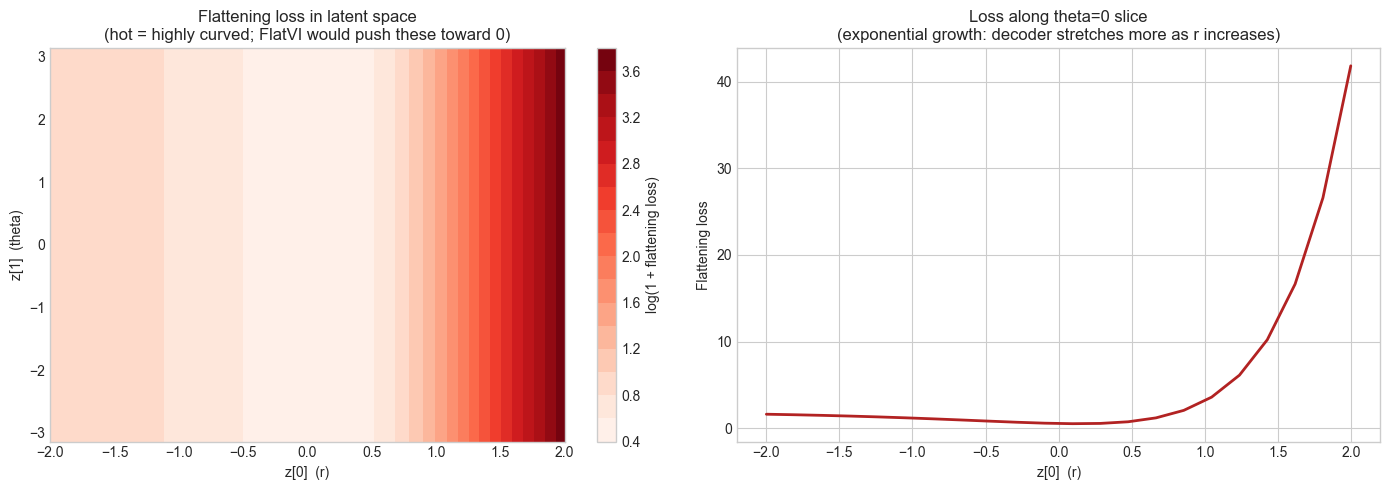

In [15]:
# Estimate optimal alpha from random samples
z_samples  = rng.uniform(low=[-2, -np.pi], high=[2, np.pi], size=(120, 2))
alpha_opt  = optimal_alpha(decoder_polar, z_samples)
print(f'Optimal alpha for polar decoder: {alpha_opt:.4f}')

# Compute loss on a grid
n_grid = 22
r_vals = np.linspace(-2, 2, n_grid)
th_vals = np.linspace(-np.pi, np.pi, n_grid)
Rg, Thg = np.meshgrid(r_vals, th_vals)
loss_grid = np.zeros((n_grid, n_grid))

for i, th in enumerate(th_vals):
    for j, r in enumerate(r_vals):
        g = pullback_metric(decoder_polar, np.array([r, th]))
        loss_grid[i, j] = flattening_loss(g, alpha=alpha_opt)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
cf = ax.contourf(Rg, Thg, np.log1p(loss_grid), levels=20, cmap='Reds')
plt.colorbar(cf, ax=ax, label='log(1 + flattening loss)')
ax.set_xlabel('z[0]  (r)')
ax.set_ylabel('z[1]  (theta)')
ax.set_title('Flattening loss in latent space\n'
             '(hot = highly curved; FlatVI would push these toward 0)')

ax = axes[1]
ax.plot(r_vals, loss_grid[n_grid // 2, :], color='firebrick', linewidth=2)
ax.set_xlabel('z[0]  (r)')
ax.set_ylabel('Flattening loss')
ax.set_title('Loss along theta=0 slice\n'
             '(exponential growth: decoder stretches more as r increases)')

plt.tight_layout()
plt.show()

### 3.3 — Effect of Flattening: LERP Becomes a Valid Geodesic

**The key claim:** if the decoder is perfectly flat ($g_Z = \alpha I$ everywhere),
then LERP in latent space produces constant-speed paths in data space
that respect the manifold structure.

**Proof:** Let $\psi$ be a flat decoder. For any latent path $z(t) = z_0 + t\,(z_1 - z_0)$:
$$\left\|\frac{d}{dt}\psi(z(t))\right\|^2 = (z_1 - z_0)^T g_Z(z(t))\,(z_1 - z_0) = \alpha\,\|z_1 - z_0\|^2 = \text{const}$$

Constant speed $\Rightarrow$ the path is arc-length parametrised $\Rightarrow$ it is a geodesic.

**Demo:** compare a curved decoder (polar, exponential scaling) vs a flat baseline
using the speed profile along a LERP path.

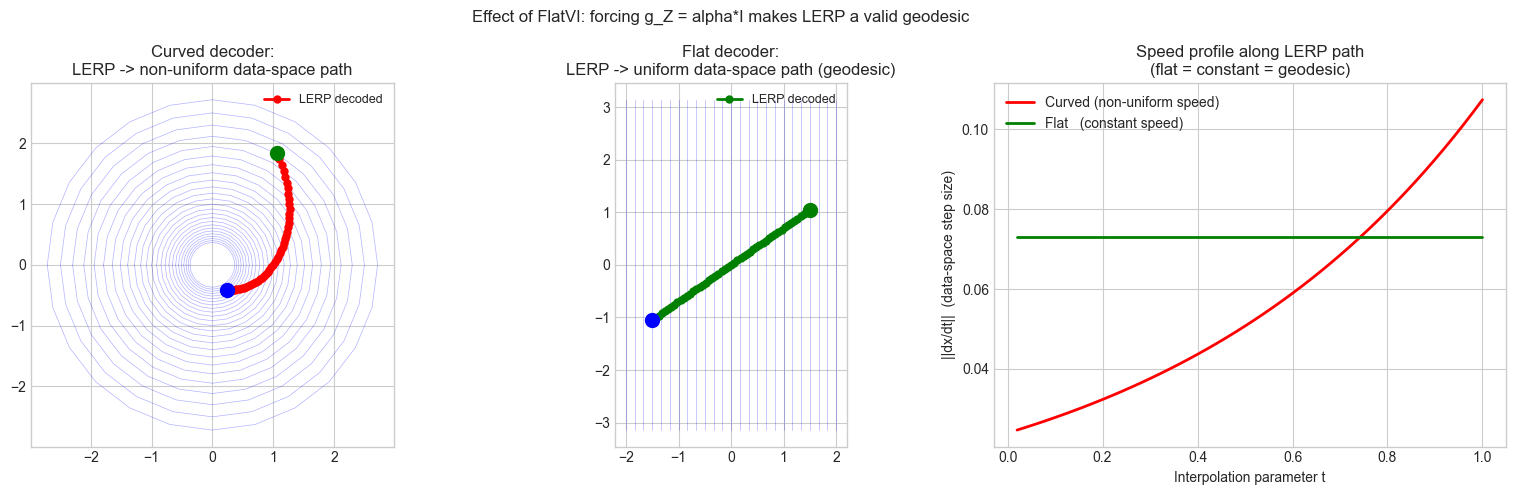

Speed coefficient of variation (0 = perfectly uniform):
  Curved decoder : 0.4251
  Flat decoder   : 1.99e-15


In [16]:
def decoder_flat(z: np.ndarray) -> np.ndarray:
    '''Linear (flat) decoder: identity — g_Z(z) = I everywhere.'''
    return np.array([z[0], z[1]])


z_s = np.array([-1.5, -np.pi / 3])
z_e = np.array([1.5,   np.pi / 3])
lerp_z = np.outer(1 - ts, z_s) + np.outer(ts, z_e)

path_curved = np.array([decoder_polar(z) for z in lerp_z])
path_flat   = np.array([decoder_flat(z)  for z in lerp_z])

# Data-space speed at each step (||x(t+dt) - x(t)||)
speed_curved = np.linalg.norm(np.diff(path_curved, axis=0), axis=1)
speed_flat   = np.linalg.norm(np.diff(path_flat,   axis=0), axis=1)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Path of curved decoder in data space
ax = axes[0]
fine_r  = np.linspace(-2, 2, 25)
fine_th = np.linspace(-np.pi, np.pi, 25)
for r_v in fine_r:
    pts = np.array([decoder_polar(np.array([r_v, th])) for th in fine_th])
    ax.plot(pts[:, 0], pts[:, 1], 'b-', linewidth=0.5, alpha=0.3)
ax.plot(path_curved[:, 0], path_curved[:, 1], 'r-o', markersize=5, linewidth=2,
        label='LERP decoded')
ax.scatter(*path_curved[0],  color='blue',  s=100, zorder=5)
ax.scatter(*path_curved[-1], color='green', s=100, zorder=5)
ax.set_aspect('equal')
ax.set_title('Curved decoder:\nLERP -> non-uniform data-space path')
ax.legend(fontsize=9)

# Path of flat decoder
ax = axes[1]
fine_pts = np.array([
    [decoder_flat(np.array([z1, z2])) for z2 in fine_th]
    for z1 in fine_r
])
for row in fine_pts:
    ax.plot(row[:, 0], row[:, 1], 'b-', linewidth=0.5, alpha=0.3)
ax.plot(path_flat[:, 0], path_flat[:, 1], 'g-o', markersize=5, linewidth=2,
        label='LERP decoded')
ax.scatter(*path_flat[0],  color='blue',  s=100, zorder=5)
ax.scatter(*path_flat[-1], color='green', s=100, zorder=5)
ax.set_aspect('equal')
ax.set_title('Flat decoder:\nLERP -> uniform data-space path (geodesic)')
ax.legend(fontsize=9)

# Speed comparison
ax = axes[2]
ax.plot(ts[1:], speed_curved, 'r-', linewidth=2, label='Curved (non-uniform speed)')
ax.plot(ts[1:], speed_flat,   'g-', linewidth=2, label='Flat   (constant speed)')
ax.set_xlabel('Interpolation parameter t')
ax.set_ylabel('||dx/dt||  (data-space step size)')
ax.set_title('Speed profile along LERP path\n(flat = constant = geodesic)')
ax.legend()

plt.suptitle('Effect of FlatVI: forcing g_Z = alpha*I makes LERP a valid geodesic', fontsize=12)
plt.tight_layout()
plt.show()

cv_curved = speed_curved.std() / speed_curved.mean()
cv_flat   = speed_flat.std()   / speed_flat.mean()
print(f'Speed coefficient of variation (0 = perfectly uniform):')
print(f'  Curved decoder : {cv_curved:.4f}')
print(f'  Flat decoder   : {cv_flat:.2e}')

---

## Summary

### Part 1 — Geodesic (05)

| Concept | Key takeaway |
|---|---|
| Geodesic | Shortest path lying entirely on the manifold |
| LERP failure | Straight line in ambient/latent space leaves the manifold |
| SLERP | Constant-angular-speed interpolation on $S^{n-1}$; stays on manifold |
| Exp/Log maps | General recipe for geodesic interpolation on any Riemannian manifold |
| Swiss Roll | LERP shortcuts through empty space — decoded outputs would be unrealistic |

### Part 2 — Pullback Metric (06)

| Concept | Key takeaway |
|---|---|
| Pullback metric | $g_Z(z) = J^T J$ — transfers data-space distances back into latent space |
| Interpretation | Eigenvalues of $g_Z$ = squared stretch factors of the decoder at $z$ |
| Flatness condition | $g_Z(z) = \alpha I$ everywhere $\Leftrightarrow$ decoder is isometric |
| Limitation | Requires computing the Jacobian at every point (expensive for large $D$) |

### Part 3 — FlatVI (07)

| Concept | Key takeaway |
|---|---|
| Flattening loss | $\|g_Z(z) - \alpha I\|_F^2$ — penalises deviation from isometric decoder |
| Joint training | Added to ELBO; decoder learns to balance reconstruction and flatness |
| Result | LERP in flat latent space = constant-speed geodesic in data space |
| Advantage over GAGA/NeuralFIM | No expensive Neural ODE solver at inference time |

> **The chain:** geodesics expose the problem $\to$ pullback metric diagnoses the distortion
> $\to$ FlatVI cures it by making the decoder isometric.